In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
from statsforecast import StatsForecast
from statsforecast.models import AutoETS, Naive
from sklearn.metrics import mean_absolute_error, mean_squared_error


In [2]:
# Load the processed dataset
df = pd.read_csv("../data/processed/processed_data.csv")
df["Date"] = pd.to_datetime(df["Date"])

print(f"Dataset shape: {df.shape}")


Dataset shape: (421570, 32)


In [ ]:
series = df[(df["Store"] == 1) &(df["Dept"] == 1)].copy()

In [ ]:
series

In [ ]:
series=series[["Date","Weekly_Sales"]]

In [ ]:
series

In [ ]:
original = series.copy()

In [ ]:
noise = np.random.normal(0, 0.03, len(series))

synthetic = series.copy()

synthetic["Weekly_Sales"] *= (1 + noise)

synthetic = series.copy()

# Shift dates by 3 years
synthetic["Date"] = synthetic["Date"] + pd.DateOffset(years=3)




In [ ]:
mask = (
    (series["Date"] >= "2011-10-25") &
    (series["Date"] <= "2012-02-03")
)

gap_data = series.loc[mask].copy()
gap_data["Date"] = gap_data["Date"] + pd.DateOffset(years=1)

print(gap_data)

In [ ]:
synthetic

In [ ]:
plt.figure(figsize=(14,5))

plt.plot(
    series["Date"],
    series["Weekly_Sales"],
    label="Original"
)

plt.plot(
    synthetic["Date"],
    synthetic["Weekly_Sales"],
    label="Synthetic"
)

plt.plot(
    gap_data["Date"],
    gap_data["Weekly_Sales"],
    label="Synthetic"
)

plt.legend()
plt.title("Store 1 - Dept 1")
plt.show()

In [ ]:
final_series = (
    pd.concat([original, gap_data, synthetic], ignore_index=True)
      .sort_values("Date")
      .drop_duplicates(subset="Date", keep="first")
      .reset_index(drop=True)
)

In [ ]:
print(final_series["Date"].min())
print(final_series["Date"].max())
print(len(final_series))

In [ ]:
plt.figure(figsize=(15,5))

plt.plot(final_series["Date"], final_series["Weekly_Sales"])

plt.title("Original + Gap Fill + Synthetic")
plt.xlabel("Date")
plt.ylabel("Weekly Sales")
plt.grid(True)

plt.show()

In [ ]:
df["Date"].max()

# generating whole data

In [3]:
df_gap = df[(df["Date"] >= "2011-11-04") & (df["Date"] <= "2012-01-27")].copy()

df_gap["Date"] = df_gap["Date"] + pd.Timedelta(weeks=52)

noise_gap = np.random.normal(0, 0.03, len(df_gap)) # normal(mean, std_dev, size) creates noise of len(df_gap)
df_gap["Weekly_Sales"] *= (1 + noise_gap)


In [4]:
df_synthetic = df.copy()

df_synthetic["Date"] = df_synthetic["Date"] + pd.Timedelta(weeks=156)

noise_syn = np.random.normal(0, 0.03, len(df_synthetic))
df_synthetic["Weekly_Sales"] *= (1 + noise_syn)


In [5]:
df_total = pd.concat([df, df_gap, df_synthetic]).sort_values(["Store", "Dept", "Date"]).reset_index(drop=True)

df_total["Year"] = df_total["Date"].dt.year
df_total["Month"] = df_total["Date"].dt.month
df_total["Week"] = df_total["Date"].dt.isocalendar().week.astype(int)

print(f"Total Combined shape: {df_total.shape}")
print(f"New timeline range: {df_total['Date'].min()} to {df_total['Date'].max()}")


Total Combined shape: (881938, 32)
New timeline range: 2010-02-05 00:00:00 to 2015-10-23 00:00:00


In [60]:
df_total["Date"].max()

Timestamp('2015-10-23 00:00:00')

In [ ]:
output_path = "../data/processed/synthetic_data.csv"
df_total.to_csv(output_path, index=False)

print(f"Saved complete synthetic dataset successfully to {output_path}!")


In [6]:
sample=df_total[(df_total["Store"]==1)&(df_total["Dept"]==1)]

In [7]:
sample #7_19

,Store,Dept,Date,Weekly_Sales,IsHoliday,Year,Month,Week,Temperature,Fuel_Price,...,Lag_2,Lag_4,Lag_8,Lag_52,Sales_Roll_Mean_4,Sales_Roll_Std_4,Sales_Roll_Mean_12,Sales_Roll_Std_12,Sales_EMA_4,Sales_EMA_12
0,1,1,2010-02-05,24924.500000,0,2010,2,5,42.31,2.572,...,NaN,NaN,NaN,NaN,NaN,0.000000,NaN,0.000000,NaN,NaN
1,1,1,2010-02-12,46039.490000,1,2010,2,6,38.51,2.548,...,NaN,NaN,NaN,NaN,24924.500000,0.000000,24924.500000,0.000000,24924.500000,24924.500000
2,1,1,2010-02-19,41595.550000,0,2010,2,7,39.93,2.514,...,24924.50,NaN,NaN,NaN,35481.995000,14930.552614,35481.995000,14930.552614,33370.496000,28172.960000
3,1,1,2010-02-26,19403.540000,0,2010,2,8,46.63,2.561,...,46039.49,NaN,NaN,NaN,37519.846667,11131.900957,37519.846667,11131.900957,36660.517600,30237.973846
4,1,1,2010-03-05,21827.900000,0,2010,3,9,46.50,2.625,...,41595.55,24924.50,NaN,NaN,32990.770000,12832.106391,32990.770000,12832.106391,29757.726560,28571.137870
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
294,1,1,2015-09-25,18181.571436,0,2015,9,39,76.08,3.666,...,19616.22,16680.24,16628.31,18337.68,18467.582500,1310.162157,17225.370833,1264.465884,18632.118474,17931.352056
295,1,1,2015-10-02,22737.845544,0,2015,10,40,68.55,3.617,...,19251.50,18322.37,16119.92,20797.58,19034.475000,547.762555,17319.074167,1351.478772,18758.395084,18087.730202
296,1,1,2015-10-09,22885.490174,0,2015,10,41,62.99,3.601,...,18947.81,19616.22,17330.70,23077.55,19930.000000,1344.377070,17763.931667,1862.931965,20016.825051,18674.920940
297,1,1,2015-10-16,23864.034000,0,2015,10,42,67.97,3.594,...,21904.47,19251.50,16286.40,23351.80,20716.947500,1904.210986,18298.594167,2291.117105,21115.699030,19304.011564


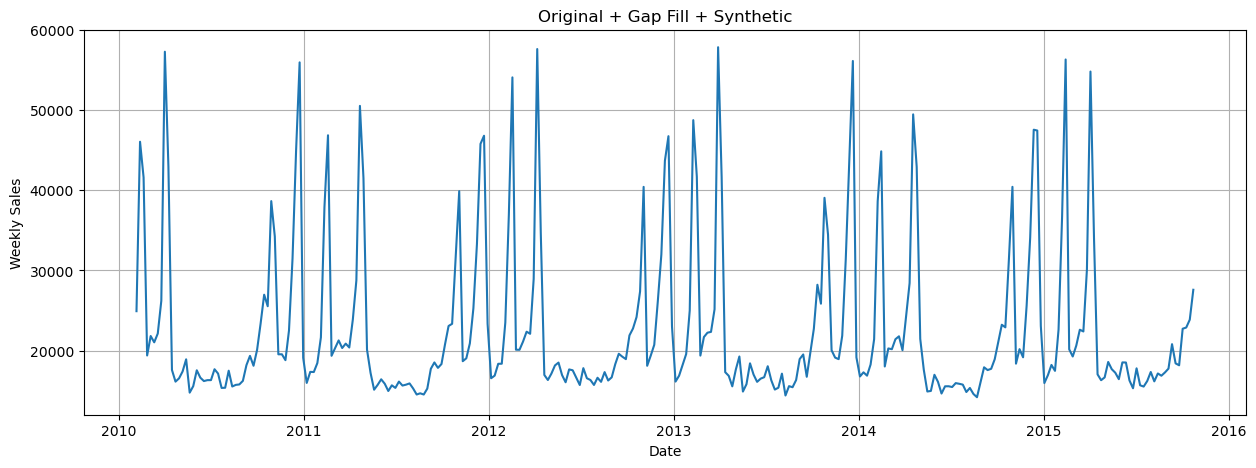

In [8]:
plt.figure(figsize=(15,5))

plt.plot(sample["Date"], sample["Weekly_Sales"])

plt.title("Original + Gap Fill + Synthetic")
plt.xlabel("Date")
plt.ylabel("Weekly Sales")
plt.grid(True)

plt.show()

# training model on new data

In [9]:

df = df_total.copy()
df["Date"] = pd.to_datetime(df["Date"])

df_new = df.rename(columns={"Store": "store", "Dept": "dept", "Date": "ds", "Weekly_Sales": "y"}).copy()
df_new["unique_id"] = df_new["store"].astype(str) + "_" + df_new["dept"].astype(str)
df_new = df_new[["unique_id", "ds", "y"]]

print(f"Dataset shape: {df_new.shape}")
print(f"Total unique store-department series: {df_new['unique_id'].nunique()}")


Dataset shape: (881938, 3)
Total unique store-department series: 3331


In [80]:
df_new["ds"].max()

Timestamp('2015-10-23 00:00:00')

In [59]:
df_new[df_new["unique_id"]=="18_51"]["y"].mean()

np.float64(7.229389195571773)

In [35]:
SPLIT_DATE = "2014-03-01"
FREQ = "W-FRI"
SEASON_LENGTH = 52

train_raw = df_new[df_new.ds <= SPLIT_DATE].copy()
valid_raw = df_new[df_new.ds > SPLIT_DATE].copy()

total_train_weeks = train_raw["ds"].nunique()
print(f"Expected weeks in training set: {total_train_weeks}")


Expected weeks in training set: 213


In [36]:
good_series_data = []
repaired_series_data = []
beyond_repair_ids = []

all_train_dates = pd.date_range(start=train_raw["ds"].min(), end=train_raw["ds"].max(), freq=FREQ, name="ds")

for uid, group in train_raw.groupby("unique_id"):
    y_vals = group["y"].values
    n_obs = len(y_vals)
    variance = np.var(y_vals) if n_obs > 0 else 0
    zero_neg_pct = np.sum(y_vals <= 0) / n_obs if n_obs > 0 else 1.0
    
    if n_obs < 56:
        beyond_repair_ids.append((uid, "Too few data points (<56 weeks)"))
        continue
    elif variance < 0.01:
        beyond_repair_ids.append((uid, "Zero/Constant Variance"))
        continue
    elif zero_neg_pct > 0.80:
        beyond_repair_ids.append((uid, "Mostly Inactive/Sparse (>80% zeros)"))
        continue
        
    missing_weeks = total_train_weeks - n_obs
    has_zeros = np.any(y_vals <= 0)
    
    p_value = 1.0
    try:
        adf_result = adfuller(y_vals, maxlag=12, autolag='AIC')
        p_value = adf_result[1]
    except Exception:
        pass
    is_stationary = (p_value < 0.05)
    
    if missing_weeks == 0 and not has_zeros and is_stationary:
        good_series_data.append(group[["unique_id", "ds", "y"]])
    else:
        repaired_group = group.set_index("ds").reindex(all_train_dates).reset_index() # reindex adds all missing weeks from all_train_dates
        repaired_group["unique_id"] = uid
        
        # repaired_group["y"] = repaired_group["y"].apply(lambda x: np.nan if x <= 0 else x)
        
        repaired_group["y"] = repaired_group["y"].interpolate(method="linear").ffill().bfill()
        
        # Clip values to a small positive floor for AutoETS
        # repaired_group["y"] = repaired_group["y"].clip(lower=0.1)
        
        repaired_group = repaired_group[["unique_id", "ds", "y"]]
        repaired_series_data.append(repaired_group)


In [37]:
df_good = pd.concat(good_series_data) if len(good_series_data) > 0 else pd.DataFrame(columns=["unique_id", "ds", "y"])
df_repaired = pd.concat(repaired_series_data) if len(repaired_series_data) > 0 else pd.DataFrame(columns=["unique_id", "ds", "y"])

train_clean = pd.concat([df_good, df_repaired]).reset_index(drop=True)
repaired_uids = df_repaired["unique_id"].unique() if not df_repaired.empty else []
good_uids = df_good["unique_id"].unique() if not df_good.empty else []
df_beyond = pd.DataFrame(beyond_repair_ids, columns=["unique_id", "reason"])

print("--- Data Repair & Filtering Report ---")
print(f"Original Series:                 {train_raw['unique_id'].nunique()}")
print(f"1. Kept without changes (Good):  {len(good_uids)}")
print(f"2. Repaired & Saved:             {len(repaired_uids)}")
print(f"3. Discarded (Beyond Repair):    {len(df_beyond)}")
print(f"--------------------------------------")
print(f"Total Series Ready for Training: {train_clean['unique_id'].nunique()}")


--- Data Repair & Filtering Report ---
Original Series:                 3331
1. Kept without changes (Good):  2274
2. Repaired & Saved:             739
3. Discarded (Beyond Repair):    318
--------------------------------------
Total Series Ready for Training: 3013


In [ ]:
output_path = "../data/processed/train_data.csv"
df_total.to_csv(output_path, index=False)

print(f"Saved complete synthetic dataset successfully to {output_path}!")


In [ ]:
output_path = "../data/processed/test_data.csv"
df_total.to_csv(output_path, index=False)

print(f"Saved complete synthetic dataset successfully to {output_path}!")


In [38]:
df_beyond

,unique_id,reason
0,10_47,Too few data points (<56 weeks)
1,10_51,Too few data points (<56 weeks)
2,10_77,Too few data points (<56 weeks)
3,10_78,Too few data points (<56 weeks)
4,11_47,Too few data points (<56 weeks)
...,...,...
313,9_78,Too few data points (<56 weeks)
314,9_80,Too few data points (<56 weeks)
315,9_93,Too few data points (<56 weeks)
316,9_97,Too few data points (<56 weeks)


In [39]:
valid_clean = valid_raw[valid_raw["unique_id"].isin(train_clean["unique_id"].unique())].copy()


In [44]:
train_clean

,unique_id,ds,y
0,10_1,2010-02-05,40212.840000
1,10_1,2010-02-12,67699.320000
2,10_1,2010-02-19,49748.330000
3,10_1,2010-02-26,33601.220000
4,10_1,2010-03-05,36572.440000
...,...,...,...
641764,9_95,2014-01-31,22770.814080
641765,9_95,2014-02-07,23287.909386
641766,9_95,2014-02-14,21264.914848
641767,9_95,2014-02-21,20581.311707


In [47]:
(641769/893449) * 100

71.83051298954949

In [45]:
valid_clean

,unique_id,ds,y
213,1_1,2014-03-07,20188.249465
214,1_1,2014-03-14,21428.008222
215,1_1,2014-03-21,21792.621833
216,1_1,2014-03-28,20057.629095
217,1_1,2014-04-04,24256.601183
...,...,...,...
881933,45_98,2015-09-25,534.002022
881934,45_98,2015-10-02,636.361322
881935,45_98,2015-10-09,1032.021447
881936,45_98,2015-10-16,723.500304


In [40]:
sf = StatsForecast(models=[AutoETS(season_length=SEASON_LENGTH, model="AAA")],freq=FREQ,fallback_model=Naive(),n_jobs=-1)

sf.fit(train_clean)
print("Training completed")


Training completed


In [70]:
sf

StatsForecast(models=[AutoETS])

In [ ]:
h = valid_clean["ds"].nunique()
print(f"Forecasting horizon: {h} weeks")

forecast = sf.predict(h=h)
print(forecast.head())


Forecasting horizon: 86 weeks
  unique_id         ds       AutoETS
0      10_1 2014-03-07  33028.142380
1      10_1 2014-03-14  35815.801696
2      10_1 2014-03-21  42007.554730
3      10_1 2014-03-28  80846.770348
4      10_1 2014-04-04  84108.671701


In [42]:
results_clean = valid_clean.merge(forecast, on=["unique_id", "ds"])

mae = np.mean(np.abs(results_clean["y"] - results_clean["AutoETS"]))
rmse = np.sqrt(np.mean((results_clean["y"] - results_clean["AutoETS"])**2))
wmape = (np.abs(results_clean["y"] - results_clean["AutoETS"]).sum() / np.abs(results_clean["y"]).sum()) * 100
accuracy = 100 - wmape

print("--- Cleaned Model Evaluation ---")
print(f"MAE:  {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"WMAPE: {wmape:.2f}%")
print(f"Overall Accuracy: {accuracy:.2f}%")


--- Cleaned Model Evaluation ---
MAE:  1419.32
RMSE: 2962.26
WMAPE: 8.82%
Overall Accuracy: 91.18%


In [18]:
results_clean

,unique_id,ds,y,AutoETS
0,1_1,2014-03-07,20188.249465,21785.487204
1,1_1,2014-03-14,21428.008222,21929.884243
2,1_1,2014-03-21,21792.621833,23069.386320
3,1_1,2014-03-28,20057.629095,40207.471237
4,1_1,2014-04-04,24256.601183,41561.396606
...,...,...,...,...
251675,45_98,2015-09-25,534.002022,122.938071
251676,45_98,2015-10-02,636.361322,237.626267
251677,45_98,2015-10-09,1032.021447,401.499596
251678,45_98,2015-10-16,723.500304,375.321091


In [56]:
results_clean[results_clean["unique_id"]=="18_51"]

,unique_id,ds,y,AutoETS
103823,18_51,2014-03-07,20.204538,9.506430
103824,18_51,2014-04-25,2.888752,3.397605
103825,18_51,2014-05-02,1.551565,2.930944
103826,18_51,2014-05-09,28.015863,11.001452
103827,18_51,2014-05-16,11.170626,6.761685
103828,18_51,2014-05-23,1.593745,3.909956
103829,18_51,2014-06-06,6.930791,-2.804946
103830,18_51,2014-06-27,2.761028,2.430387
103831,18_51,2014-07-04,7.082631,9.129809
103832,18_51,2014-07-11,9.594221,11.543041


In [43]:
def calculate_series_wmape(group):
    actual = group['y']
    predicted = group['AutoETS']  
    
    if actual.sum() <= 5: 
        return np.nan
        
    return (np.abs(actual - predicted).sum() / actual.sum()) * 100

series_errors = results_clean.groupby('unique_id').apply(calculate_series_wmape).reset_index(name='wmape')

worst_series = series_errors.dropna().sort_values(by='wmape', ascending=False)

print("--- WORST PERFORMING STORE-DEPARTMENTS (Highest wMAPE) ---")
print(worst_series.head(15).to_string(index=False))


--- WORST PERFORMING STORE-DEPARTMENTS (Highest wMAPE) ---
unique_id      wmape
    43_85 955.017321
    35_49 925.794306
     7_19 828.078817
    32_51 519.438692
    34_51 433.422072
    35_54 382.703060
    11_54 367.321774
    31_51 351.910634
    35_51 338.766183
    11_51 312.391811
    34_54 294.898540
    23_54 294.342344
    39_54 294.312630
    19_51 276.658861
    32_54 271.775606


In [20]:
worst_series

,unique_id,wmape
2465,43_85,955.017321
1914,35_49,925.794306
2816,7_19,828.078817
1726,32_51,519.438692
1846,34_51,433.422072
...,...,...
31,10_4,3.184923
2035,37_91,3.115101
1837,34_40,3.101404
150,12_13,2.918970


In [21]:
worst_series[worst_series["wmape"]<5]

,unique_id,wmape
2397,42_4,4.988374
177,12_40,4.988287
270,13_74,4.981456
1650,31_46,4.978603
2419,42_91,4.965184
...,...,...
31,10_4,3.184923
2035,37_91,3.115101
1837,34_40,3.101404
150,12_13,2.918970


In [22]:
worst_series[worst_series["wmape"]>20]

,unique_id,wmape
2465,43_85,955.017321
1914,35_49,925.794306
2816,7_19,828.078817
1726,32_51,519.438692
1846,34_51,433.422072
...,...,...
1966,36_46,20.131311
2891,8_21,20.115813
2209,3_56,20.083108
188,12_56,20.061716


In [102]:
worst_series[worst_series["unique_id"]=="1_1"]

,unique_id,wmape
713,1_1,12.170245


In [50]:
from sklearn.metrics import mean_absolute_error

def calculate_series_mae(group):
    return mean_absolute_error(group["y"], group["AutoETS"])

series_errors = results_clean.groupby('unique_id').apply(calculate_series_mae).reset_index(name='mae')

worst_series_mae = series_errors.dropna().sort_values(by='mae', ascending=False)

print("--- WORST PERFORMING STORE-DEPARTMENTS (Highest MAE) ---")
print(worst_series_mae.head(15).to_string(index=False))


--- WORST PERFORMING STORE-DEPARTMENTS (Highest MAE) ---
unique_id          mae
     3_38 16236.723798
    13_92 15206.120027
    38_38 14925.899793
    14_95 13985.333089
    18_72 13666.661464
    18_92 13496.833620
     4_95 13395.563322
    36_94 13216.254034
    14_92 13022.563169
     4_92 12497.449821
    10_72 12302.573097
    39_92 12185.950461
    23_92 11974.179442
    20_92 11842.760895
    35_72 10982.503286


In [51]:
worst_series_mae

,unique_id,mae
2196,3_38,16236.723798
282,13_92,15206.120027
2063,38_38,14925.899793
356,14_95,13985.333089
623,18_72,13666.661464
...,...,...
611,18_51,4.789175
2633,4_45,4.304294
1968,36_52,3.525469
2067,38_44,3.050827


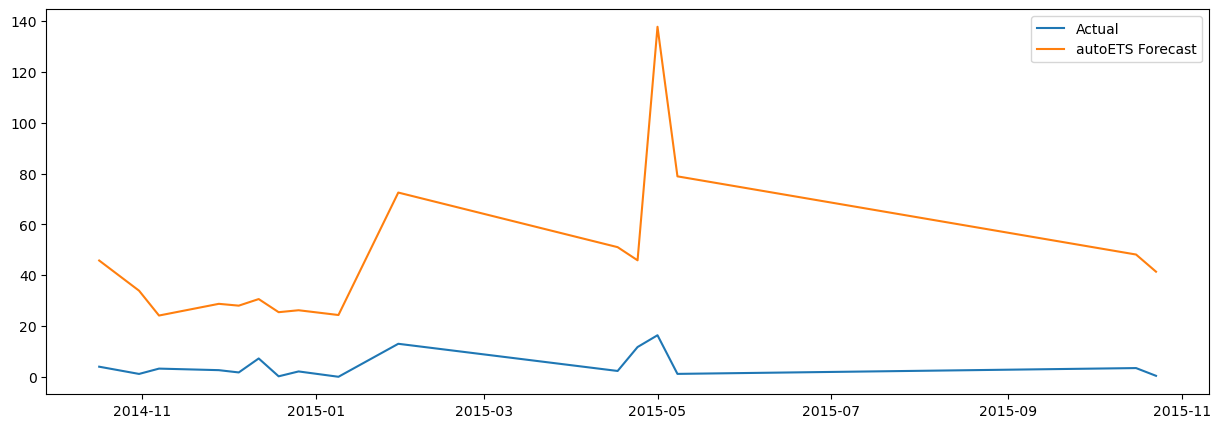

In [104]:
sample = "43_85"

actual = results_clean[
    results_clean["unique_id"] == sample
]

plt.figure(figsize=(15,5))

plt.plot(
    actual["ds"],
    actual["y"],
    label="Actual"
)

plt.plot(
    actual["ds"],
    actual["AutoETS"],
    label="autoETS Forecast"
)

plt.legend()

plt.show()

In [72]:
df_new

,unique_id,ds,y
0,1_1,2010-02-05,24924.500000
1,1_1,2010-02-12,46039.490000
2,1_1,2010-02-19,41595.550000
3,1_1,2010-02-26,19403.540000
4,1_1,2010-03-05,21827.900000
...,...,...,...
881933,45_98,2015-09-25,534.002022
881934,45_98,2015-10-02,636.361322
881935,45_98,2015-10-09,1032.021447
881936,45_98,2015-10-16,723.500304


In [73]:
sf = StatsForecast(models=[AutoETS(season_length=SEASON_LENGTH, model="AAA")],freq=FREQ,fallback_model=Naive(),n_jobs=-1)

sf.fit(df_new)
print("Training completed")

forecast = sf.predict(h=52)
print(forecast.head())



Training completed
  unique_id         ds       AutoETS
0      10_1 2015-10-30  76720.554011
1      10_1 2015-11-06  32168.681164
2      10_1 2015-11-13  32667.620675
3      10_1 2015-11-20  36468.133273
4      10_1 2015-11-27  49315.562467


In [74]:
forecast

,unique_id,ds,AutoETS
0,10_1,2015-10-30,76720.554011
1,10_1,2015-11-06,32168.681164
2,10_1,2015-11-13,32667.620675
3,10_1,2015-11-20,36468.133273
4,10_1,2015-11-27,49315.562467
...,...,...,...
173207,9_98,2016-04-15,13.350995
173208,9_98,2016-04-22,13.504613
173209,9_98,2016-04-29,13.658231
173210,9_98,2016-05-06,13.811848


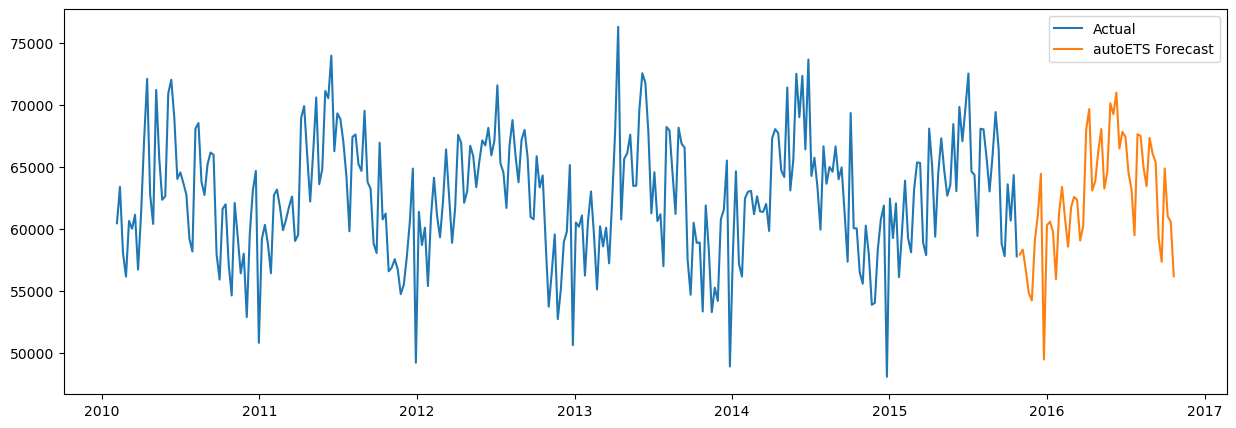

In [106]:

sample = "8_95"
previous=df_new[df_new["unique_id"] == sample]
forcast_val = forecast[forecast["unique_id"] == sample]

plt.figure(figsize=(15,5))

plt.plot(
    previous["ds"],
    previous["y"],
    label="Actual"
)

plt.plot(
    forcast_val["ds"],
    forcast_val["AutoETS"],
    label="autoETS Forecast"
)

plt.legend()

plt.show()

In [94]:
forcast_val

,unique_id,ds,AutoETS
89232,30_26,2015-07-10,2.154122
89233,30_26,2015-07-17,12.799213
89234,30_26,2015-07-24,12.805544
89235,30_26,2015-07-31,6.507823
89236,30_26,2015-08-07,18.121626
89237,30_26,2015-08-14,3.557025
89238,30_26,2015-08-21,16.526562
89239,30_26,2015-08-28,3.494011
89240,30_26,2015-09-04,9.360129
89241,30_26,2015-09-11,4.565916


In [107]:
previous[previous["ds"]=="2014/09/12"]

,unique_id,ds,y
163830,8_95,2014-09-12,64951.758026
